In [6]:
from collections import Counter
import json
from pathlib import Path
import random
import re
from typing import List


from IPython.display import display, Markdown
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm
import textwrap


from langchain_core.documents import Document
from langchain_ollama import OllamaEmbeddings


from transformers import AutoTokenizer

from typing import Literal
from pydantic import BaseModel, Field

pd.set_option('display.precision', 2)
pd.set_option('display.float_format', '{:.2f}'.format)

In [4]:
with open('../data/articles.json', 'r', encoding='utf-8') as f:
    articles = json.load(f)
    
with open('../data/ground_truth.json', 'r', encoding='utf-8') as f:
    ground_truth = json.load(f)

with open('../data/questions.json', 'r', encoding='utf-8') as f:
    questions = json.load(f)

1. Проверка на дубликатыы

In [5]:
print(f"Количество дубликатов в текстах: ", len(set([article['text'] for article in articles])) - len([article['text'] for article in articles]))
print(f"Количество дубликатов в топиках: ", len(set([article['title'] for article in articles])) - len([article['title'] for article in articles]))

Количество дубликатов в текстах:  0
Количество дубликатов в топиках:  0


2. Посмотрим на среднее и оценим разброс

In [6]:
length_text, length_topic = [], []
for article in articles:
    length_text.append(len(article['text']))
    length_topic.append(len(article['title']))

print(f'Средняя длина заголовка: {np.mean(length_topic):.1f}')
print(f"Средняя длина текста: {np.mean(length_text):.1f}")
pd.DataFrame({'Длина текстов': length_text,
              'Длина топика': length_topic,
              'Отклонение от средней длины текста': (length_text - np.mean(length_text)) * 100 / np.mean(length_text), 
              'Отклонение от среднего длины топика': (length_topic - np.mean(length_topic)) * 100 / np.mean(length_topic)
              })

Средняя длина заголовка: 47.6
Средняя длина текста: 784.8


,Длина текстов,Длина топика,Отклонение от средней длины текста,Отклонение от среднего длины топика
0,866,55,10.35,15.55
1,823,49,4.87,2.94
2,730,41,-6.98,-13.87
3,805,52,2.57,9.24
4,772,43,-1.63,-9.66
5,728,50,-7.24,5.04
6,785,55,0.03,15.55
7,767,55,-2.27,15.55
8,754,32,-3.92,-32.77
9,818,44,4.23,-7.56


3. Посмотрим на случайные документы. Проверим, есть ли артефакты или мусор в статье

In [7]:
for article in random.sample(articles, 5):
    print(article['title'])
    print(article['text'])
    print('=' * 80)

Руководство по управлению доступами и ролями
Доступы в корпоративных системах выдаются по принципу минимально необходимых привилегий и только на основании утвержденной заявки в AccessFlow. Стандартный срок действия временных доступов — 14 календарных дней с автоматическим отзывом в 23:59 последнего дня. Все привилегированные роли уровня admin требуют двойного согласования: руководителя функции и службы информационной безопасности. Ежеквартально владельцы систем обязаны проводить access review и подтверждать актуальность прав пользователей; неподтвержденные права блокируются через 5 рабочих дней после завершения кампании review. Для подрядчиков максимальный срок доступа ограничен датой контракта, но не более 90 дней без повторного согласования. Передача учетных данных третьим лицам запрещена и квалифицируется как грубое нарушение политики безопасности.
Положение о резервном копировании и восстановлении
Для всех продакшн-сервисов применяются политики резервного копирования по схеме 3-2-1

- Данные достаточно качественные, в них нет мусора, артефактов
- Топик по смыслу совпадает с текстом

4. Проверим распределение токенов

Средняя коли токена: 258.0
Максимальное количество токенов: 294


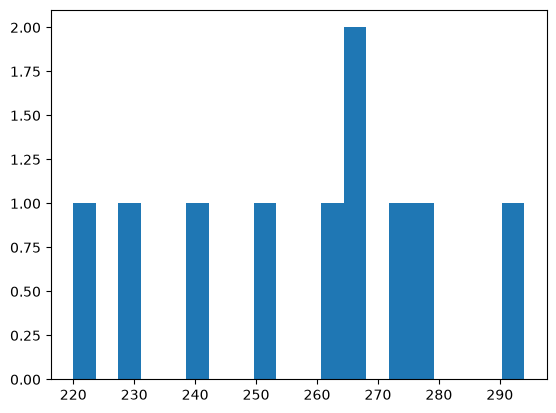

In [8]:
tokenizer = AutoTokenizer.from_pretrained('Qwen/Qwen3-4b')

length_token = (
    [
        len(tokenizer.encode(article['text'], add_special_token=False)) 
        for article in articles
    ]
)

print(f'Средняя коли токена: {np.mean(length_token):.1f}')
print(f'Максимальное количество токенов: {max(length_token)}')
plt.hist(length_token, bins=20);

In [1]:
import os
import random

os.chdir("..")

In [2]:
from src.evaluation import extract_answers, compute_bleu, compute_rouge
from src.data_loader import load_json, merge_questions_and_answers
from src.retrieval import retrieve_documents, build_context
from src.generation import answer_without_rag, answer_with_rag
from src.judge import judge_answer, explain_judgement
from src.indexing import create_documents, build_embeddings
from src.save_json import save_json

In [3]:
article_path = "data/articles.json"
question_path = "data/questions.json"
answers_path = "data/ground_truth.json"

articles = load_json(article_path)
questions = load_json(question_path)
answers = load_json(answers_path)

question_answer = merge_questions_and_answers(questions, answers)

In [41]:
documents = create_documents(articles)
article_embeddings = build_embeddings(documents)
data_sample = random.sample(question_answer, 1)[0]

In [42]:
retrieve_doc = retrieve_documents(
    data_sample['question'],
    documents,
    article_embeddings
)

context = build_context(retrieve_doc)
plain_answer = answer_without_rag(data_sample['question'])
rag_answer = answer_with_rag(data_sample['question'], context)

In [43]:
results = {
    "question": data_sample["question"],
    "ground_truth_answer": data_sample["answer"],
    "llm_answer": plain_answer,
    "rag_answer": rag_answer,
    "retrieved": [
        {
            "document_id": result["document"].metadata["id"],
            "score": result["score"]
        }
        for result in retrieve_doc
    ],
    "relevant_document_id": data_sample["relevant_document_id"],
    "context": context
}

In [44]:
results

{'question': 'С какой периодичностью делаются инкрементальные бэкапы?',
 'ground_truth_answer': 'Инкрементальные бэкапы делаются каждые 30 минут.',
 'llm_answer': 'Инкрементальные бэкапы делаются с периодичностью, установленной пользователем или системой — например, каждые 15 минут, каждый час или ежедневно. Периодичность зависит от конкретной конфигурации системы, приложения или политики резервного копирования.\n\nОтвет: **зависит от настроек системы**.',
 'rag_answer': 'Инкрементальные бэкапы делаются каждые 30 минут.',
 'retrieved': [{'document_id': '6', 'score': 0.5416432764635409},
  {'document_id': '5', 'score': 0.34018082865702004},
  {'document_id': '7', 'score': 0.3257687229407944}],
 'relevant_document_id': '6',
 'context': 'Документ 1\n\n    Заголовок:\n    Положение о резервном копировании и восстановлении\n\n    Содержимое:\n    Для всех продакшн-сервисов применяются политики резервного копирования по схеме 3-2-1: три копии данных, два разных типа носителей, одна копия вне

In [8]:
label_partial = judge_answer(question=query_partial,
             context=context, 
             reference_answer="SOC зафиксировал всплеск в 09:12 14 марта 2026 года.",
             candidate_answer="SOC зафиксировал всплеск переходов по подозрительным ссылкам в 09:12.").label

NameError: name 'query_partial' is not defined

In [9]:
query_incorrect = "Какой лимит на проживание по Европе указан в документе о командировках?"

retrieve_doc = retrieve_documents(
    query_incorrect,
    documents,
    article_embeddings
)

context = build_context(retrieve_doc)

In [10]:
label_incorrect = judge_answer(question=query_incorrect,
             context=context,
             reference_answer="Лимит на проживание по Европе — 160 евро за ночь.",
             candidate_answer="16 евро").label

In [ ]:
explain_judgement(question=query_incorrect,
             context=context,
             reference_answer="Лимит на проживание по Европе — 160 евро за ночь.",
             candidate_answer="16 евро",
             label=label_incorrect)

JudgeExplanation(reason='Кандидат указал 16 евро, а в документе указано 160 евро.')

In [29]:
query_correct = "Что происходит с неподтвержденными правами после квартального access review?"

retrieve_doc = retrieve_documents(
    query_correct,
    documents,
    article_embeddings
)

context = build_context(retrieve_doc)

In [30]:
label_correct =judge_answer(question=query_correct,
             context=context,
             reference_answer="Неподтвержденные права блокируются через 5 рабочих дней после завершения review.",
             candidate_answer="Неподтвержденные права блокируются через 5 рабочих дней после завершения кампании access review.").label

In [31]:
explain_judgement(question=query_correct,
             context=context,
             reference_answer="Неподтвержденные права блокируются через 5 рабочих дней после завершения review.",
             candidate_answer="Неподтвержденные права блокируются через 5 рабочих дней после завершения кампании access review.",
             label=label_correct)

JudgeExplanation(reason='Ответ кандидата точно соответствует описанию в документе 1 по сроку блокировки неподтвержденных прав после access review.')

In [19]:
llm_predictions, references = extract_answers(result, "llm_answer")
rag_predictions, references = extract_answers(result, "rag_answer")

llm_bleu = compute_bleu(llm_predictions, references)
rag_bleu = compute_bleu(rag_predictions, references)

llm_rouge = compute_rouge(llm_predictions, references)
rag_rouge = compute_rouge(rag_predictions, references)

In [22]:
metrics = pd.DataFrame({"LLM": [llm_bleu, llm_rouge], "RAG": [rag_bleu, rag_rouge]}, index=['Bleu', 'Rouge-L'])

In [23]:
metrics

,LLM,RAG
Bleu,0.00823,0.308920
Rouge-L,0.02399,0.799941


In [10]:
for item in results:
    human_label = item["human_feedback"]
    judge_label_value = item["judge_label"]

    if (
        judge_label_value != human_label
        or judge_label_value in {"partial", "incorrect"}
    ):
        explanation = explain_judgement(
            question=item["question"],
            context=item["context"],
            reference_answer=item["ground_truth_answer"],
            candidate_answer=item["rag_answer"],
            label=judge_label_value,
        )

        item["judge_reason"] = explanation.reason

In [16]:
from collections import Counter, defaultdict

results = load_json("data/llm_answers_labeled.json")

labels = [result['judge_label'] for result in results]
count_label = Counter(labels)

count_label

Counter({'correct': 47, 'partial': 2, 'incorrect': 1})

In [17]:
for result in results:
    if result['judge_label'] in ('partial', 'incorrect'):
        print(f"Метка: {result['judge_label']}")
        print("================================================================================================")
        print(f"Вопрос: {result["question"]}")
        print("================================================================================================")
        print(f"Истинный ответ: {result["ground_truth_answer"]}")
        print("================================================================================================")
        print(f"Ответ модели: {result["rag_answer"]}")
        print("""
              --------------------------------------------------------------------------------------------------
              --------------------------------------------------------------------------------------------------
              """)

Метка: incorrect
Вопрос: Какой лимит на проживание по Европе указан в документе о командировках?
Истинный ответ: Лимит на проживание по Европе — 160 евро за ночь.
Ответ модели: 16 евро

              --------------------------------------------------------------------------------------------------
              --------------------------------------------------------------------------------------------------
              
Метка: partial
Вопрос: Когда SOC зафиксировал всплеск переходов по подозрительным ссылкам в инциденте ИБ-24-117?
Истинный ответ: SOC зафиксировал всплеск в 09:12 14 марта 2026 года.
Ответ модели: SOC зафиксировал всплеск переходов по подозрительным ссылкам в 09:12.

              --------------------------------------------------------------------------------------------------
              --------------------------------------------------------------------------------------------------
              
Метка: partial
Вопрос: До какого дня нужно завершить курс по защи

In [18]:
human_feedback_result = load_json("data/llm_answers_labeled.json")

In [19]:
llm_as_judge_metrics = defaultdict(int)

for result in human_feedback_result:
    llm_as_judge_metrics['matches'] += result['judge_label'] == result['human_label']
    llm_as_judge_metrics['mismatchess'] += result['judge_label'] != result['human_label']
    if result['judge_label'] != result['human_label']:
        print(f"Метка: {result['judge_label']}")
        print("================================================================================================")
        print(f"Вопрос: {result["question"]}")
        print("================================================================================================")
        print(f"Истинный ответ: {result["ground_truth_answer"]}")
        print("================================================================================================")
        print(f"Ответ модели: {result["rag_answer"]}")
        print("""
              --------------------------------------------------------------------------------------------------
              --------------------------------------------------------------------------------------------------
              """)
    
llm_as_judge_metrics['agreements'] = llm_as_judge_metrics['matches'] / len(results)

Метка: partial
Вопрос: До какого дня нужно завершить курс по защите персональных данных?
Истинный ответ: Курс по защите персональных данных нужно завершить до 10-го дня.
Ответ модели: До 10-го дня онбординга.

              --------------------------------------------------------------------------------------------------
              --------------------------------------------------------------------------------------------------
              


In [35]:
results

[{'question': 'Когда SOC зафиксировал всплеск переходов по подозрительным ссылкам в инциденте ИБ-24-117?',
  'ground_truth_answer': 'SOC зафиксировал всплеск в 09:12 14 марта 2026 года.',
  'llm_answer': 'Не знаю.',
  'rag_answer': 'SOC зафиксировал всплеск переходов по подозрительным ссылкам в 09:12.',
  'retrieved': [{'document_id': '1', 'score': 0.6390631085328579},
   {'document_id': '5', 'score': 0.32020034251771196},
   {'document_id': '10', 'score': 0.3119157963006004}],
  'relevant_document_id': '2',
  'context': 'Документ 1\n\n    Заголовок:\n    Регламент оформления командировок и возмещения расходов\n\n    Содержимое:\n    С 1 января 2026 года в компании действует обновленный регламент командировок. Заявка оформляется в системе TravelHub не позднее чем за 5 рабочих дней до выезда и должна быть согласована руководителем подразделения и финансовым контролером. Базовый лимит на проживание по России установлен в размере 9000 рублей за ночь, по СНГ — 12000 рублей, по Европе — 160

In [45]:
results = [results]

In [ ]:
def compute_recall_at_k(results: list[dict], k: int = 3) -> float:
    """
    Вычисляет Recall@k для retrieval.
    Args:
        results: результаты retrieval с relevant_document_id
                и списком retrieved документов.
        k: количество первых retrieved документов для проверки.
    Returns:
        Доля вопросов, для которых релевантный документ попал в top-k.
    """
    recall_k = 0
    
    for result in results:
        relevant_doc = result['relevant_document_id'] 
        for retrieved_doc  in result['retrieved'][:k]:
            if retrieved_doc['document_id'] == relevant_doc:
                recall_k += 1
                break
    
    return recall_k / len(results)

In [53]:
compute_recall_at_k(results, 7)

1.0

In [30]:
result

{'question': 'Что происходит с неподтвержденными правами после квартального access review?',
 'ground_truth_answer': 'Неподтвержденные права блокируются через 5 рабочих дней после завершения review.',
 'llm_answer': 'Не знаю.',
 'rag_answer': 'Неподтвержденные права блокируются через 5 рабочих дней после завершения кампании access review.',
 'retrieved': [{'document_id': '10', 'score': 0.593608474222858},
  {'document_id': '2', 'score': 0.39967146542299775},
  {'document_id': '6', 'score': 0.3532763511508238}],
 'context': 'Документ 1\n\n    Заголовок:\n    Руководство по управлению доступами и ролями\n\n    Содержимое:\n    Доступы в корпоративных системах выдаются по принципу минимально необходимых привилегий и только на основании утвержденной заявки в AccessFlow. Стандартный срок действия временных доступов — 14 календарных дней с автоматическим отзывом в 23:59 последнего дня. Все привилегированные роли уровня admin требуют двойного согласования: руководителя функции и службы информ